# Task 3 - sample-efficiency curve

> *"Retrain the registry with only 1, 2, 5, 10, and 20 confirmed examples per
> category, then evaluate each version, and plot accuracy vs n. This is meant
> to demonstrate something a neural baseline structurally can't match - a
> usable category from a handful of real examples."*

## Scope

The SAGE half of this needs `train_registry_multiview.py` plus a local
YCB-Video copy. This checkout has the script, but `image_sets/train.txt` and
`image_sets/val.txt` are empty stubs and there is no dataset root - so the
registry curve **cannot** be run from the exported `.npz` files.

What runs here is the other half of the same comparison: the learned-baseline
curve, over the same n values, on the same held-out instances. That is the
reference curve the registry gets plotted against. Drop the five registry
numbers into `SAGE_REFERENCE_CURVE` in `src/task3_sample_efficiency.py` and
both appear on one axis.

## One design decision that matters

*n examples per category* is counted in **distinct physical objects**, not
rows. Drawing n rows at random would usually draw n views of the same object,
which is not "n confirmed examples" in the sense the guide means. Training and
evaluation objects are kept strictly disjoint.

In [1]:
import sys
from pathlib import Path

# Use the project's src/ modules rather than re-implementing anything here.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import results_io as rio
import viz_style as vs

vs.apply_style()
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

print("Reading results from:", rio.RESULTS_DIR)


Reading results from: C:\Users\suraj\Desktop\ICRA\sage_baseline_experiments\results


In [2]:
from data_utils import load_pointcloud_data, compute_object_groups

clouds, labels = load_pointcloud_data()
groups = compute_object_groups(clouds, distance_threshold=0.003)

available = (
    pd.DataFrame({"label": labels, "group": groups})
    .groupby("label")["group"].nunique()
    .reindex(rio.CLASSES)
    .rename("distinct_objects")
    .to_frame()
)
available["in_train_pool_approx"] = (available["distinct_objects"] * 0.7).astype(int)
available

,distinct_objects,in_train_pool_approx
label,,
box,93,65
can,55,38
mug,22,15
bottle,58,40
bowl,26,18


This is why the curve stops at n = 10: bowl has only 26 distinct objects, so
after holding out an evaluation pool there are not 20 left to draw from. The
script skips a budget rather than quietly reporting a curve point built from
fewer examples than it claims.

In [3]:
summary = rio.load_sample_efficiency()

pivot = summary.pivot(index="n_per_class", columns="model",
                      values="overall_accuracy_mean")
(pivot * 100).round(1)

model,knn,svm_linear,svm_rbf
n_per_class,,,
1,53.4,53.4,53.4
2,54.1,60.0,53.8
5,56.5,63.0,60.7
10,68.8,69.0,67.0


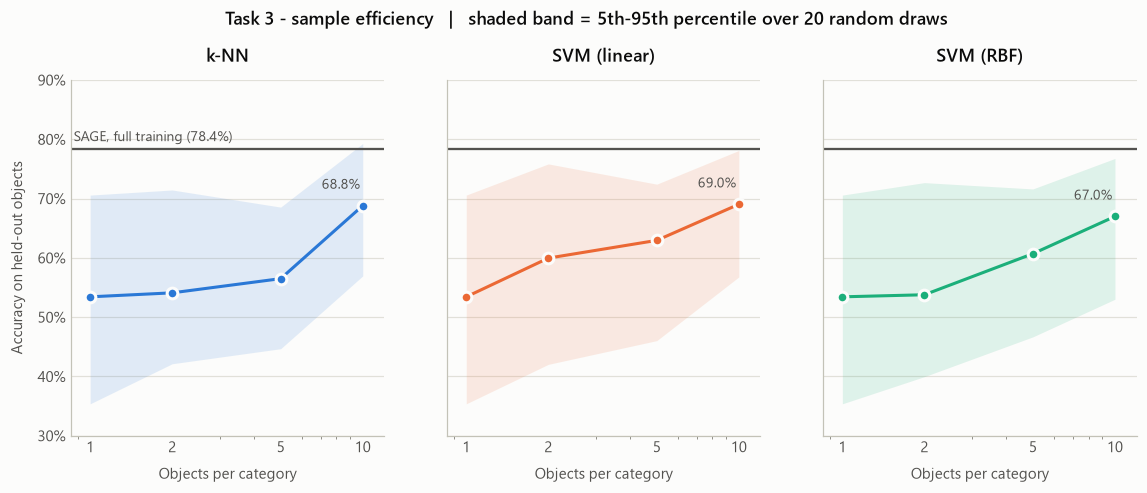

In [4]:
# Three overlapping uncertainty bands on one axis turn into mud, and the
# k-NN / linear-SVM endpoints collide at n=10. Small multiples instead:
# one panel per model, each with its own band and a single end label.
colors = {"knn": vs.BLUE, "svm_linear": vs.ORANGE, "svm_rbf": vs.AQUA}
sizes = sorted(summary["n_per_class"].unique())

fig, axes = plt.subplots(1, 3, figsize=(12.5, 4.2), sharey=True)

for ax, model in zip(axes, ["knn", "svm_linear", "svm_rbf"]):
    model_df = summary[summary["model"] == model].sort_values("n_per_class")
    color = colors[model]

    ax.fill_between(model_df["n_per_class"],
                    model_df["p05"] * 100, model_df["p95"] * 100,
                    color=color, alpha=0.13, linewidth=0)

    ax.plot(model_df["n_per_class"], model_df["overall_accuracy_mean"] * 100,
            marker="o", color=color,
            markeredgecolor=vs.SURFACE, markeredgewidth=2)

    last = model_df.iloc[-1]
    ax.annotate(f"{last['overall_accuracy_mean'] * 100:.1f}%",
                xy=(last["n_per_class"], last["overall_accuracy_mean"] * 100),
                xytext=(-2, 11), textcoords="offset points",
                ha="right", fontsize=9, color=vs.INK_SECONDARY)

    ax.axhline(78.4, color=vs.SAGE_COLOR, linewidth=1.5)

    ax.set_xscale("log")
    ax.set_xticks(sizes)
    ax.set_xticklabels([str(s) for s in sizes])
    ax.set_xlim(0.85, 12)
    ax.set_xlabel("Objects per category")
    ax.set_title(rio.pretty(model))
    vs.percent_axis(ax, "y", lo=30, top=90, step=10)

axes[0].set_ylabel("Accuracy on held-out objects")
axes[0].annotate("SAGE, full training (78.4%)", xy=(0.87, 78.4), xytext=(0, 5),
                 textcoords="offset points", fontsize=9, color=vs.SAGE_COLOR)

fig.suptitle("Task 3 - sample efficiency   |   shaded band = 5th-95th "
             "percentile over 20 random draws",
             y=1.03, fontsize=12, fontweight="semibold")
plt.show()

## Reading this

- At **one** object per category all three land on 53.4% - with five training
  points total, k-NN, linear SVM and RBF SVM all reduce to roughly the same
  nearest-prototype rule.
- The percentile bands are enormous at small n (roughly 35-70% at n = 1). Which
  single bowl you happen to draw matters more than which classifier you use.
- At n = 10 the baselines reach ~69%, still short of SAGE's full-training
  78.4% - though that line is a *different* training regime, not a fair n-shot
  comparison, which is exactly why the registry curve is the missing piece.

**This does not yet test the guide's claim.** Showing that the registry beats
these curves at small n needs the registry curve. Happy to plot it the moment
those five numbers exist.

In [5]:
# Spread across draws, to make the small-n instability concrete.
detail = summary[["model", "n_per_class", "overall_accuracy_mean",
                  "overall_accuracy_std", "p05", "p95", "n_trials"]].copy()
for column in ["overall_accuracy_mean", "overall_accuracy_std", "p05", "p95"]:
    detail[column] = (detail[column] * 100).round(1)
detail.reset_index(drop=True)

,model,n_per_class,overall_accuracy_mean,overall_accuracy_std,p05,p95,n_trials
0,knn,1,53.4,11.8,35.4,70.6,20
1,knn,2,54.1,12.4,42.1,71.5,20
2,knn,5,56.5,8.9,44.7,68.6,20
3,knn,10,68.8,7.3,57.0,79.3,20
4,svm_linear,1,53.4,11.8,35.4,70.6,20
5,svm_linear,2,60.0,13.3,42.0,75.8,20
6,svm_linear,5,63.0,9.6,46.0,72.4,20
7,svm_linear,10,69.0,7.6,56.8,78.1,20
8,svm_rbf,1,53.4,11.8,35.4,70.6,20
9,svm_rbf,2,53.8,13.1,40.0,72.7,20
